In [1]:
import tensorflow as tf

tf.__version__

'2.19.0'

### Fashion Mnist

In [6]:
# load the data
fashion = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion.load_data()

In [8]:
len(x_train), len(x_test)

(60000, 10000)

In [9]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [10]:
# noramlize the data
x_train  = x_train / 255.0
x_test = x_test / 255.0

### Visualize the images

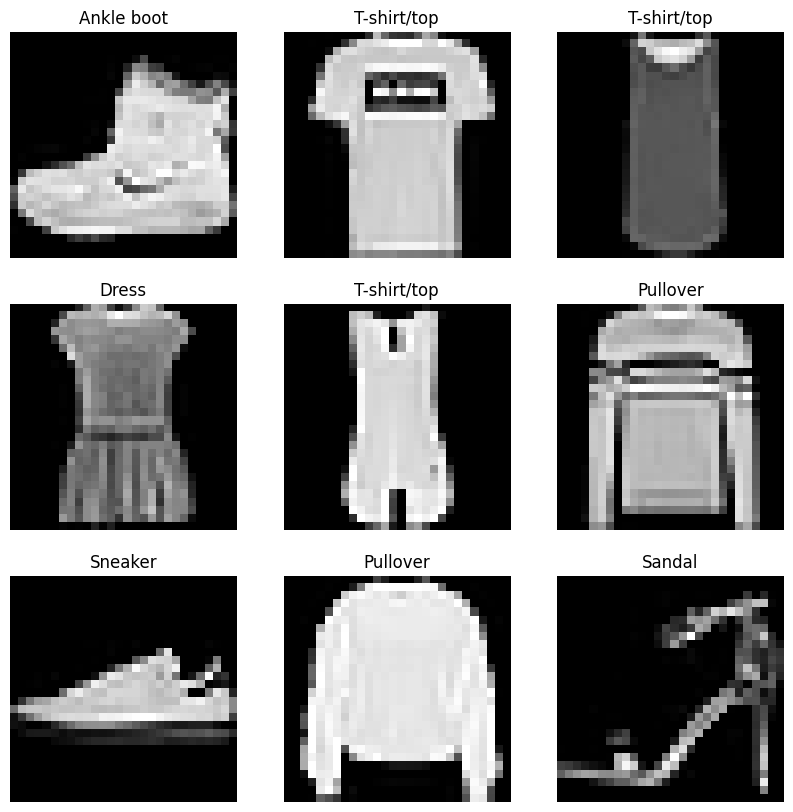

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
    plt.title(class_names[y_train[i].item()])


In [22]:
y_train[0].item()

9

In [25]:
x_train[0].shape

(28, 28)

In [36]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

In [37]:
model.predict(tf.expand_dims(x_train[0], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[-0.03043915, -0.05751227, -0.13526128,  0.82029915, -0.09880763,
        -0.29553148, -0.72764957, -0.58424866, -1.0026869 ,  0.91891426]],
      dtype=float32)

In [38]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)


model.compile(loss=loss_fn,  optimizer="adam", metrics=["accuracy"])

In [41]:
model.fit(x_train, y_train, epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 644us/step - accuracy: 0.9586 - loss: 0.1055
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 583us/step - accuracy: 0.9585 - loss: 0.1069
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step - accuracy: 0.9587 - loss: 0.1056
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 595us/step - accuracy: 0.9596 - loss: 0.1071
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.9574 - loss: 0.1131
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 587us/step - accuracy: 0.9608 - loss: 0.1012
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step - accuracy: 0.9605 - loss: 0.1024
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 596us/step - accuracy: 0.9592 - loss: 0.1082
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.9591 - loss: 0.1074
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 588us/step - accuracy: 0.9614 - loss: 0.1007
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - accuracy: 0.9594 - loss: 0.10

In [42]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step - accuracy: 0.8890 - loss: 0.7561


[0.7488384246826172, 0.8884000182151794]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


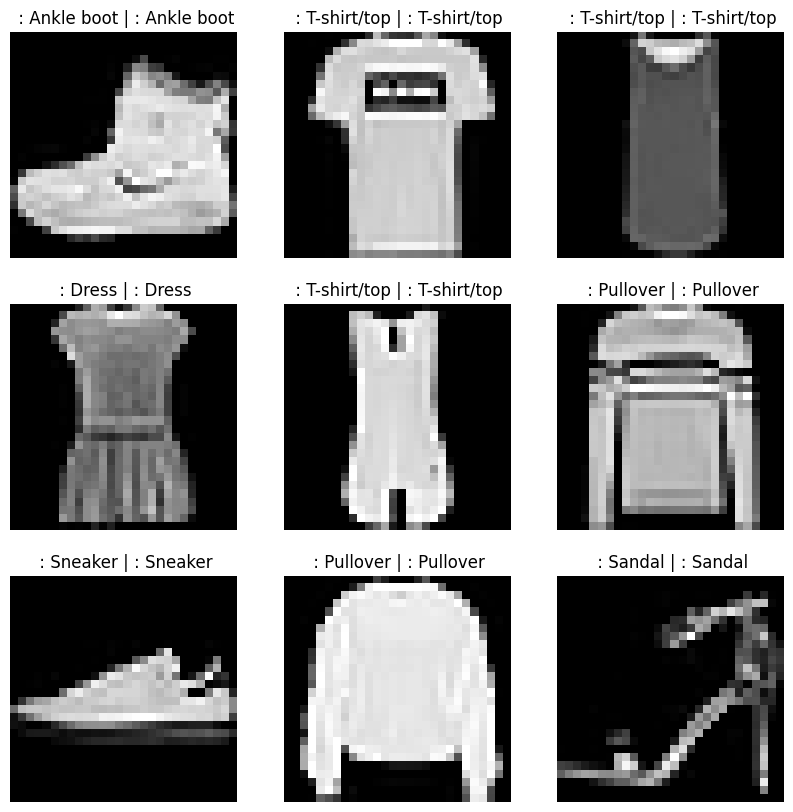

In [78]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
    diz = model.predict(tf.expand_dims(x_train[i], axis=0))
    plt.title(f" : {class_names[y_train[i].item()]} | : {class_names[tf.argmax(diz, axis=1).numpy().item()]}")
    


In [83]:
diz = model.predict(tf.expand_dims(x_train[0], axis=0))

tf.nn.softmax(diz, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 5.3188184e-19, 0.0000000e+00, 3.5609209e-12,
        0.0000000e+00, 1.0000000e+00]], dtype=float32)>